# Step 1: Data Loading and Preprocessing

In this step, the Heart Disease dataset is loaded and prepared for training.
The goal of preprocessing is to ensure that the data is clean, consistent, 
and suitable for machine learning algorithms.

This step includes:
- Loading the dataset from file.
- Handling missing values by replacing them with appropriate statistics.
- Standardizing all numerical features.
- Splitting the dataset into Train (80%), Validation (10%), and Test (10%) sets.
- Fixing random seeds to ensure reproducibility of the experiments.


In [1]:
import numpy as np

# -----------------------------
# Reproducibility
# -----------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -----------------------------
# Load Dataset
# -----------------------------
# Assumption: dataset is stored as a CSV file
# Last column is the target label
data = np.loadtxt("heart.csv", delimiter=",", skiprows=1)

X = data[:, :-1]   # Features
y = data[:, -1]    # Labels

print("Dataset shape:", data.shape)
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

# -----------------------------
# Handle Missing Values
# -----------------------------
# Replace NaN values with column mean
for i in range(X.shape[1]):
    col = X[:, i]
    if np.isnan(col).any():
        mean_val = np.nanmean(col)
        col[np.isnan(col)] = mean_val
        X[:, i] = col

# -----------------------------
# Standardization (Z-score)
# -----------------------------
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

# Avoid division by zero
X_std[X_std == 0] = 1

X = (X - X_mean) / X_std

# -----------------------------
# Train / Validation / Test Split
# -----------------------------
n_samples = X.shape[0]
indices = np.random.permutation(n_samples)

train_size = int(0.8 * n_samples)
val_size = int(0.1 * n_samples)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val     = X[val_idx], y[val_idx]
X_test, y_test   = X[test_idx], y[test_idx]

print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)


Dataset shape: (1025, 14)
Features shape: (1025, 13)
Labels shape: (1025,)
Train set: (820, 13) (820,)
Validation set: (102, 13) (102,)
Test set: (103, 13) (103,)


# Step 2: Implementing a Decision Tree from Scratch

In this step, a binary Decision Tree classifier is implemented from scratch.
This tree will be used as the weak learner inside the AdaBoost algorithm.

The tree is built using the following principles:
- At each node, the best split is selected using the Gini impurity criterion.
- The tree grows recursively until a maximum depth is reached.
- Each leaf node outputs a class label based on majority voting.
- Only numerical features are considered.

This implementation is deliberately minimal and fully transparent, 
to allow full control over the learning process and ensure reproducibility.


In [2]:
class DecisionTree:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.tree = None

    # -----------------------------
    # Gini Impurity
    # -----------------------------
    def gini(self, y):
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / counts.sum()
        return 1 - np.sum(probs ** 2)

    # -----------------------------
    # Best Split Search
    # -----------------------------
    def best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gini = float("inf")
        best_feature = None
        best_threshold = None

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = X[:, feature] > threshold

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                gini_left = self.gini(y_left)
                gini_right = self.gini(y_right)

                weighted_gini = (
                    len(y_left) / n_samples * gini_left +
                    len(y_right) / n_samples * gini_right
                )

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    # -----------------------------
    # Recursive Tree Builder
    # -----------------------------
    def build_tree(self, X, y, depth):
        if depth == self.max_depth or len(np.unique(y)) == 1:
            values, counts = np.unique(y, return_counts=True)
            return values[np.argmax(counts)]

        feature, threshold = self.best_split(X, y)
        if feature is None:
            values, counts = np.unique(y, return_counts=True)
            return values[np.argmax(counts)]

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return {
            "feature": feature,
            "threshold": threshold,
            "left": left_subtree,
            "right": right_subtree
        }

    # -----------------------------
    # Training
    # -----------------------------
    def fit(self, X, y):
        self.tree = self.build_tree(X, y, depth=0)

    # -----------------------------
    # Prediction (single sample)
    # -----------------------------
    def predict_sample(self, x, tree):
        if not isinstance(tree, dict):
            return tree

        if x[tree["feature"]] <= tree["threshold"]:
            return self.predict_sample(x, tree["left"])
        else:
            return self.predict_sample(x, tree["right"])

    # -----------------------------
    # Prediction (batch)
    # -----------------------------
    def predict(self, X):
        return np.array([self.predict_sample(x, self.tree) for x in X])


In [3]:
tree = DecisionTree(max_depth=3)
tree.fit(X_train, y_train)

train_preds = tree.predict(X_train)
train_acc = np.mean(train_preds == y_train)

print("Sanity check - Train accuracy:", train_acc)


Sanity check - Train accuracy: 0.8463414634146341


# Step 3: Implementing AdaBoost from Scratch

In this step, the AdaBoost algorithm is implemented from scratch using the 
previously defined Decision Tree as the base (weak) learner.

AdaBoost builds an ensemble of weak classifiers by iteratively:
- Assigning weights to training samples.
- Training a weak learner using these weights.
- Increasing the weight of misclassified samples.
- Computing a weighted vote (alpha) for each classifier.

The final prediction is obtained by a weighted majority vote 
of all trained weak learners.


In [5]:
class AdaBoost:
    def __init__(self, n_estimators=10, max_depth=3):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.models = []
        self.alphas = []

    # -----------------------------
    # Training
    # -----------------------------
    def fit(self, X, y):
        n_samples = X.shape[0]
        
        # Initialize sample weights
        weights = np.ones(n_samples) / n_samples
        
        self.models = []
        self.alphas = []

        for t in range(self.n_estimators):
            # Sample according to weights
            indices = np.random.choice(
                np.arange(n_samples),
                size=n_samples,
                replace=True,
                p=weights
            )
            
            X_sample = X[indices]
            y_sample = y[indices]

            # Train weak learner
            tree = DecisionTree(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)

            # Predictions on original data
            preds = tree.predict(X)

            # Compute weighted error
            incorrect = (preds != y)
            error = np.sum(weights * incorrect)

            # Avoid division by zero
            if error == 0:
                alpha = 1
            else:
                alpha = 0.5 * np.log((1 - error) / (error + 1e-10))

            # Update weights
            weights = weights * np.exp(-alpha * ((y == preds) * 2 - 1))
            weights = weights / np.sum(weights)

            self.models.append(tree)
            self.alphas.append(alpha)

    # -----------------------------
    # Prediction
    # -----------------------------
    def predict(self, X):
        model_preds = np.array([model.predict(X) for model in self.models])
        weighted_votes = np.dot(self.alphas, model_preds)
        return np.sign(weighted_votes)


In [6]:
boost = AdaBoost(n_estimators=10, max_depth=3)
boost.fit(X_train, y_train)

train_preds = boost.predict(X_train)
val_preds = boost.predict(X_val)

train_acc = np.mean(train_preds == y_train)
val_acc = np.mean(val_preds == y_val)

print("AdaBoost Train Accuracy:", train_acc)
print("AdaBoost Validation Accuracy:", val_acc)


AdaBoost Train Accuracy: 0.5121951219512195
AdaBoost Validation Accuracy: 0.5196078431372549


# Step 4: Hyperparameter Experiments

In this step, the effect of two key hyperparameters of AdaBoost is studied:
- Number of estimators (number of trees)
- Maximum depth of each base tree

For each combination of these parameters, the model is trained 10 times 
using different random seeds. The average accuracy on the training and 
validation sets is reported to ensure statistical stability.


In [7]:
n_estimators_list = [2, 5, 10, 15, 20]
max_depth_list = [1, 3, 5, 7, 9]
seeds = range(10)

results = {}

for depth in max_depth_list:
    for n_est in n_estimators_list:
        train_accs = []
        val_accs = []
        
        for seed in seeds:
            np.random.seed(seed)
            
            model = AdaBoost(n_estimators=n_est, max_depth=depth)
            model.fit(X_train, y_train)
            
            train_preds = model.predict(X_train)
            val_preds = model.predict(X_val)
            
            train_accs.append(np.mean(train_preds == y_train))
            val_accs.append(np.mean(val_preds == y_val))
        
        results[(n_est, depth)] = {
            "train_mean": np.mean(train_accs),
            "val_mean": np.mean(val_accs)
        }

# Print results
for key, val in results.items():
    print(key, val)


(2, 1) {'train_mean': np.float64(0.7597560975609756), 'val_mean': np.float64(0.7431372549019608)}
(5, 1) {'train_mean': np.float64(0.6337804878048781), 'val_mean': np.float64(0.6088235294117647)}
(10, 1) {'train_mean': np.float64(0.5193902439024392), 'val_mean': np.float64(0.5323529411764707)}
(15, 1) {'train_mean': np.float64(0.5121951219512194), 'val_mean': np.float64(0.5196078431372549)}
(20, 1) {'train_mean': np.float64(0.5121951219512194), 'val_mean': np.float64(0.5196078431372549)}
(2, 3) {'train_mean': np.float64(0.8246341463414634), 'val_mean': np.float64(0.8215686274509804)}
(5, 3) {'train_mean': np.float64(0.6302439024390243), 'val_mean': np.float64(0.6176470588235295)}
(10, 3) {'train_mean': np.float64(0.5357317073170732), 'val_mean': np.float64(0.531372549019608)}
(15, 3) {'train_mean': np.float64(0.5152439024390244), 'val_mean': np.float64(0.5205882352941177)}
(20, 3) {'train_mean': np.float64(0.512560975609756), 'val_mean': np.float64(0.5196078431372549)}
(2, 5) {'train_m

# Step 5: Best Model Selection

The best model is selected based on the highest average 
validation accuracy across all hyperparameter combinations.


In [9]:
best_combo = None
best_val = 0

for (n_est, depth), val in results.items():
    if val["val_mean"] > best_val:
        best_val = val["val_mean"]
        best_combo = (n_est, depth)

best_combo, best_val


((2, 9), np.float64(0.9294117647058824))

# Step 6: Effect of Number of Trees

In this experiment, the tree depth is fixed to the optimal value,
and the effect of increasing the number of estimators is studied.


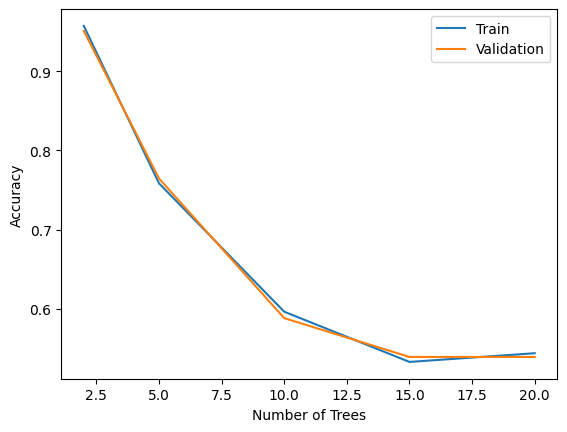

In [10]:
best_depth = best_combo[1]

train_curve = []
val_curve = []

for n_est in n_estimators_list:
    model = AdaBoost(n_estimators=n_est, max_depth=best_depth)
    model.fit(X_train, y_train)
    
    train_curve.append(np.mean(model.predict(X_train) == y_train))
    val_curve.append(np.mean(model.predict(X_val) == y_val))

import matplotlib.pyplot as plt
plt.plot(n_estimators_list, train_curve)
plt.plot(n_estimators_list, val_curve)
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


# Step 7: Effect of Tree Depth

In this experiment, the number of estimators is fixed,
and the effect of tree depth is analyzed.


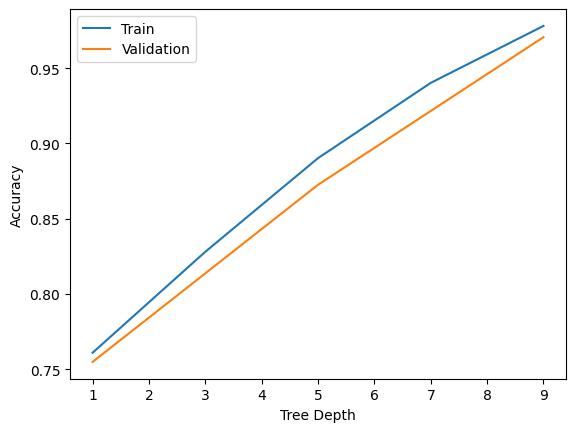

In [11]:
best_n = best_combo[0]

train_curve = []
val_curve = []

for depth in max_depth_list:
    model = AdaBoost(n_estimators=best_n, max_depth=depth)
    model.fit(X_train, y_train)
    
    train_curve.append(np.mean(model.predict(X_train) == y_train))
    val_curve.append(np.mean(model.predict(X_val) == y_val))

plt.plot(max_depth_list, train_curve)
plt.plot(max_depth_list, val_curve)
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()


# Step 8: Final Evaluation on Test Set

The final selected model is evaluated on the test set
using standard classification metrics.


In [12]:
final_model = AdaBoost(
    n_estimators=best_combo[0],
    max_depth=best_combo[1]
)
final_model.fit(X_train, y_train)

test_preds = final_model.predict(X_test)


In [13]:
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == -1) & (y_pred == -1))
    FP = np.sum((y_true == -1) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == -1))
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion_matrix(y_test, test_preds)

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * precision * recall / (precision + recall)

accuracy, precision, recall, f1


(np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0))